# Analysis for the Friedman benchmark

TODO Update with new SRB samples

The data sets are:

1. `f1a`: $f_1$ on 100 data points, no distractors
2. `f1b`: $f_1$ on 1000 data points, no distractors
3. `f1c`: $f_1$ on 100 data points, 5 columns of distractors
4. `f1d`: $f_1$ on 1000 data points, 5 columns of distractors

## Prelude

In [1]:
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import sympy

import AnalysisUtils as au

In [3]:
from sympy.abc import a, b, c, d, e, f, g, x

## Loading data

In [4]:
f1expr = sympy.sympify("10*sin(π*x1*x2) + 20*(x3 - 1/2)^2 + 10*x4 + 5*x5")
f1expr

10*x4 + 5*x5 + 20*(x3 - 1/2)**2 + 10*sin(x1*x2*π)

In [5]:
sympy.expand(f1expr)

20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(x1*x2*π) + 5

These are the results of Jessamine symbolic regression.

In [6]:
full_report = pd.read_csv("For-analysis/full-report.csv")

In [7]:
full_report["sympy"] = full_report.expr_original_syms.apply(au.parse_if_needed)
full_report["sympy_defuzz"] = full_report.expr_original_syms_defuzz.apply(au.parse_if_needed)

In [8]:
full_report.run_set.unique()

<StringArray>
[       'SRB-2026-07-13-1130', 'SRB-2026-07-13-1130-subset',
        'SRB-2026-08-03-1000', 'SRB-2026-08-03-1000-subset']
Length: 4, dtype: str

Make rows indexable by run set, data set, and sample number.

In [9]:
full_report.sort_values(["run_set", "data_set", "mse"], inplace=True)
fr2 = full_report.set_index(["run_set", "data_set", "sample_num"])

In [10]:
all_min_mse_ixs = fr2.groupby(level=["run_set", "data_set"]).mse.idxmin()
fr2.loc[all_min_mse_ixs]

rating           mse  \
run_set                    data_set sample_num                               
SRB-2026-07-13-1130        f1a      26          8.253434e-10  1.248742e-10   
                           f1aw     26          1.108323e-05  1.516981e-09   
                           f1b      22          1.407933e-09  4.799536e-10   
                           f1bw     24          1.606642e-09  8.192347e-10   
                           f1c      26          1.375129e-09  7.888702e-10   
                           f1cw     21          2.217379e-03  2.117253e-03   
                           f1d      3           5.025905e-09  3.912821e-09   
                           f1dw     1           4.329323e+01  4.329323e+01   
SRB-2026-07-13-1130-subset f1b      16          1.046489e-09  1.168499e-10   
                           f1bw     23          1.649974e-09  5.196099e-10   
                           f1d      15          2.320721e-09  2.311356e-09   
                           f1dw     3           1.106098e-09  1.077324e-09   
SRB-2026-08-03-1000        f1a      11          5.297258e-08  3.573983e-10   
                           f1aw     8           5.987422e-08  2.168418e-09   
                           f1b      15          6.623499e-08  6.293399e-10   
                           f1bw     22          1.299802e-08  1.388238e-09   
                           f1c      24          8.326184e-08  7.178968e-10   
                           f1cw     12          3.511811e+01  3.511811e+01   
                           f1d      30          5.296139e-08  6.840010e-10   
                           f1dw     11          2.387683e+00  2.387366e+00   
SRB-2026-08-03-1000-subset f1b      3           4.596454e-08  6.016977e-10   
                           f1bw     21          6.256271e-08  3.357735e-10   
                           f1d      27          5.176057e-08  8.484545e-10   
                           f1dw     18          2.259417e-08  3.267439e-09   

                                                complexity  complexity_defuzz  \
run_set                    data_set sample_num                                  
SRB-2026-07-13-1130        f1a      26                  34                 31   
                           f1aw     26                  38                 25   
                           f1b      22                  33                 24   
                           f1bw     24                  53                 23   
                           f1c      26                  54                 47   
                           f1cw     21                  46                 20   
                           f1d      3                   42                 33   
                           f1dw     1                  127                125   
SRB-2026-07-13-1130-subset f1b      16                  53                 45   
                           f1bw     23                  51                 22   
                           f1d      15                  23                 23   
                           f1dw     3                   50                 21   
SRB-2026-08-03-1000        f1a      11                  33                 33   
                           f1aw     8                  163                 25   
                           f1b      15                  57                 30   
                           f1bw     22                  42                 27   
                           f1c      24                  31                 31   
                           f1cw     12                  31                 31   
                           f1d      30                  37                 37   
                           f1dw     11                 102                 47   
SRB-2026-08-03-1000-subset f1b      3                   47                 25   
                           f1bw     21                  33                 21   
                           f1d      27                  57                 52   


In [11]:
srb2_key = "SRB-2026-07-13-1130"
srb3_key = "SRB-2026-08-03-1000"
srb2 = fr2.loc[srb2_key]
srb2s = fr2.loc[srb2_key + "-subset"]
srb3 = fr2.loc[srb3_key]
srb3s = fr2.loc[srb3_key + "-subset"]

In [12]:
srb2.groupby(level=["data_set"]).size()

data_set
f1a     32
f1aw    32
f1b     32
f1bw    32
f1c     32
f1cw    32
f1d     32
f1dw    32
dtype: int64

In [13]:
srb2s.groupby(level=["data_set"]).size()

data_set
f1b     32
f1bw    32
f1d     32
f1dw    32
dtype: int64

These are the best ones overall

In [14]:
srb2_min_mse_ixs = srb2.groupby(level=["data_set"]).mse.idxmin()
srb2s_min_mse_ixs = srb2s.groupby(level=["data_set"]).mse.idxmin()
srb3_min_mse_ixs = srb3.groupby(level=["data_set"]).mse.idxmin()
srb3s_min_mse_ixs = srb3s.groupby(level=["data_set"]).mse.idxmin()

In [15]:
srb2.loc[srb2_min_mse_ixs, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
f1a,26,1.248742e-10,31,-1.52578027578061e-5*x1 + 9.99998701857433*x4 ...
f1aw,26,1.516981e-09,25,252.313247696941*x3 + 10*x4 + 5*x5 + 20*(x3 - ...
f1b,22,4.799536e-10,24,-1.48599153158781e-5*x1 + 10.0000101668718*x4 ...
f1bw,24,8.192347e-10,23,20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
f1c,26,7.888702e-10,47,9.99998106922204*x4 + 5*x5 + 2.81716847103553e...
f1cw,21,2.117253e-03,20,19.9906962124119*x3**2 - 20.0010253883771*x3 +...
f1d,3,3.912821e-09,33,-6.22871643652014e-5*x1 + 19.9999534201764*x3*...
f1dw,1,4.329323e+01,125,0.000211053984327941*x2 + 10.1522174894659*x4 ...


In [16]:
srb2s.loc[srb2s_min_mse_ixs, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
f1b,16,1.168499e-10,45,-1.18628272329238e-5*x2 + 10.0004093488786*x3 ...
f1bw,23,5.196099e-10,22,10*x4 + 5*x5 + 20*(x3 - 0.499997096830635)**2 ...
f1d,15,2.311356e-09,23,20.0000319301576*x3**2 - 20*x3 + 10.0000104488...
f1dw,3,1.077324e-09,21,10*x4 + 5*x5 + 19.9999871489559*(x3 - 0.500000...


In [17]:
srb3.loc[srb3_min_mse_ixs, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
f1a,11,3.573983e-10,33,-2.71385194641236e-5*x2 + 20.0005010773629*x3 ...
f1aw,8,2.168418e-09,25,-9.30614829232016*x3 + 10.0000175078237*x4 + 5...
f1b,15,6.293399e-10,30,19.9997141567395*x3**2 - 19.9998259163948*x3 +...
f1bw,22,1.388238e-09,27,5*x3 + 10*x4 + 5*x5 + 5*(2*x3 - 1.250001285887...
f1c,24,7.178968e-10,31,5.00836880276035e-5*x2 + 10*x4 + 4.99998506382...
f1cw,12,3.511811e+01,31,9.7807043800199*x4 + 5.72746977268689*x5 + 19....
f1d,30,6.840010e-10,37,0.000128481772769577*x1 + 0.000118114811039772...
f1dw,11,2.387366e+00,47,0.00110802339071461*x3 + 9.92291283945829*x4 +...


## Main results

In [18]:
srb_key = srb2_key
srb = srb2
srb_min_mse_ixs = srb2_min_mse_ixs
srbs_key = srb2_key + "-subset"
srbs = srb2s
srbs_min_mse_ixs = srb2s_min_mse_ixs

In [19]:
au.mse_threshold_table(fr2)

mse_min       mse_med  \
run_set                    data_set                               
SRB-2026-07-13-1130        f1a       1.248742e-10  2.001564e-09   
                           f1aw      1.516981e-09  3.755892e+01   
                           f1b       4.799536e-10  1.707670e-02   
                           f1bw      8.192347e-10  4.424037e+01   
                           f1c       7.888702e-10  3.029212e-02   
                           f1cw      2.117253e-03  3.859515e+01   
                           f1d       3.912821e-09  6.504085e-01   
                           f1dw      4.329323e+01  4.597417e+01   
SRB-2026-07-13-1130-subset f1b       1.168499e-10  8.460265e-09   
                           f1bw      5.196099e-10  5.685221e+01   
                           f1d       2.311356e-09  2.495000e-02   
                           f1dw      1.077324e-09  6.175747e+01   
SRB-2026-08-03-1000        f1a       3.573983e-10  2.525311e-09   
                           f1aw      2.168418e-09  3.693558e+01   
                           f1b       6.293399e-10  4.994683e-02   
                           f1bw      1.388238e-09  4.350053e+01   
                           f1c       7.178968e-10  2.300989e-02   
                           f1cw      3.511811e+01  3.878888e+01   
                           f1d       6.840010e-10  9.055174e-01   
                           f1dw      2.387366e+00  4.597668e+01   
SRB-2026-08-03-1000-subset f1b       6.016977e-10  1.022924e-06   
                           f1bw      3.357735e-10  5.164643e+01   
                           f1d       8.484545e-10  7.343308e-03   
                           f1dw      3.267439e-09  5.752514e+01   

                                           mse_max  mse00  mse04  mse08  \
run_set                    data_set                                       
SRB-2026-07-13-1130        f1a        4.853596e-02     32     27     21   
                           f1aw       3.978175e+01      5      5      2   
                           f1b        1.056577e+00     30      8      5   
                           f1bw       4.614006e+01      4      4      4   
                           f1c        1.007441e+00     31     10      7   
                           f1cw       4.127671e+01      1      0      0   
                           f1d        2.425069e+00     18      2      1   
                           f1dw       4.618357e+01      0      0      0   
SRB-2026-07-13-1130-subset f1b        9.555254e+03     31     22     16   
                           f1bw       2.956983e+06      3      3      3   
                           f1d        1.798620e+09     25      7      4   
                           f1dw       3.225194e+10      1      1      1   
SRB-2026-08-03-1000        f1a        1.333615e-02     32     25     19   
                           f1aw       3.994133e+01      3      3      1   
                           f1b        1.128105e+00     31      7      3   
                           f1bw       4.609352e+01      3      3      3   
                           f1c        9.210308e-01     32      8      5   
                           f1cw       4.053894e+01      0      0      0   
                           f1d        2.176959e+00     17      1      1   
                           f1dw       4.625357e+01      0      0      0   
SRB-2026-08-03-1000-subset f1b        6.184896e-02     32     23     12   
                           f1bw       1.880214e+02      3      2      2   
                           f1d        3.704949e+02     29     12      7   
                           f1dw      1.398008e+291      2      2      2   

                                     mse12  mse16  mse20  mse24  mse28  mse32  
run_set                    data_set                                            
SRB-2026-07-13-1130        f1a           0      0      0      0      0      0  
                           f1aw          0      0      0      0      0      0  
                           f

In [20]:
srb_threshold_table = au.mse_threshold_table(fr2.loc[[srb_key]])
srb_threshold_table.to_csv("Generated/srb_threshold_table.csv")
srb_threshold_table.to_latex("Generated/srb_threshold_table.tex")
srb_threshold_table

mse_min       mse_med    mse_max  mse00  \
run_set             data_set                                                 
SRB-2026-07-13-1130 f1a       1.248742e-10  2.001564e-09   0.048536     32   
                    f1aw      1.516981e-09  3.755892e+01  39.781753      5   
                    f1b       4.799536e-10  1.707670e-02   1.056577     30   
                    f1bw      8.192347e-10  4.424037e+01  46.140057      4   
                    f1c       7.888702e-10  3.029212e-02   1.007441     31   
                    f1cw      2.117253e-03  3.859515e+01  41.276715      1   
                    f1d       3.912821e-09  6.504085e-01   2.425069     18   
                    f1dw      4.329323e+01  4.597417e+01  46.183566      0   

                              mse04  mse08  mse12  mse16  mse20  mse24  mse28  \
run_set             data_set                                                    
SRB-2026-07-13-1130 f1a          27     21      0      0      0      0      0   
                    f1aw          5      2      0      0      0      0      0   
                    f1b           8      5      0      0      0      0      0   
                    f1bw          4      4      0      0      0      0      0   
                    f1c          10      7      0      0      0      0      0   
                    f1cw          0      0      0      0      0      0      0   
                    f1d           2      1      0      0      0      0      0   
                    f1dw          0      0      0      0      0      0      0   

                              mse32  
run_set             data_set         
SRB-2026-07-13-1130 f1a           0  
                    f1aw          0  
                    f1b           0  
                    f1bw          0  
                    f1c           0  
                    f1cw          0  
                    f1d           0  
                    f1dw          0

In [21]:
plot_params = {
    "complexity_lims": (0, 449),
    "complexity_col": "complexity_defuzz",
    "mse_lims": (1.0e-12, 0.99e2),
    "complexity_binwidth": 20,
    "mse_binwidth": 0.8,
    #"spiffy_titles": ["f1a", "f1b", "f1c", "f1d"],
    "xlabel": "Complexity (defuzzed)",
    "ylabel": "MSE",
}

In [22]:
plot_params_bd = {
    **plot_params,
    #"spiffy_titles": ["f1b", "f1d"]
    }

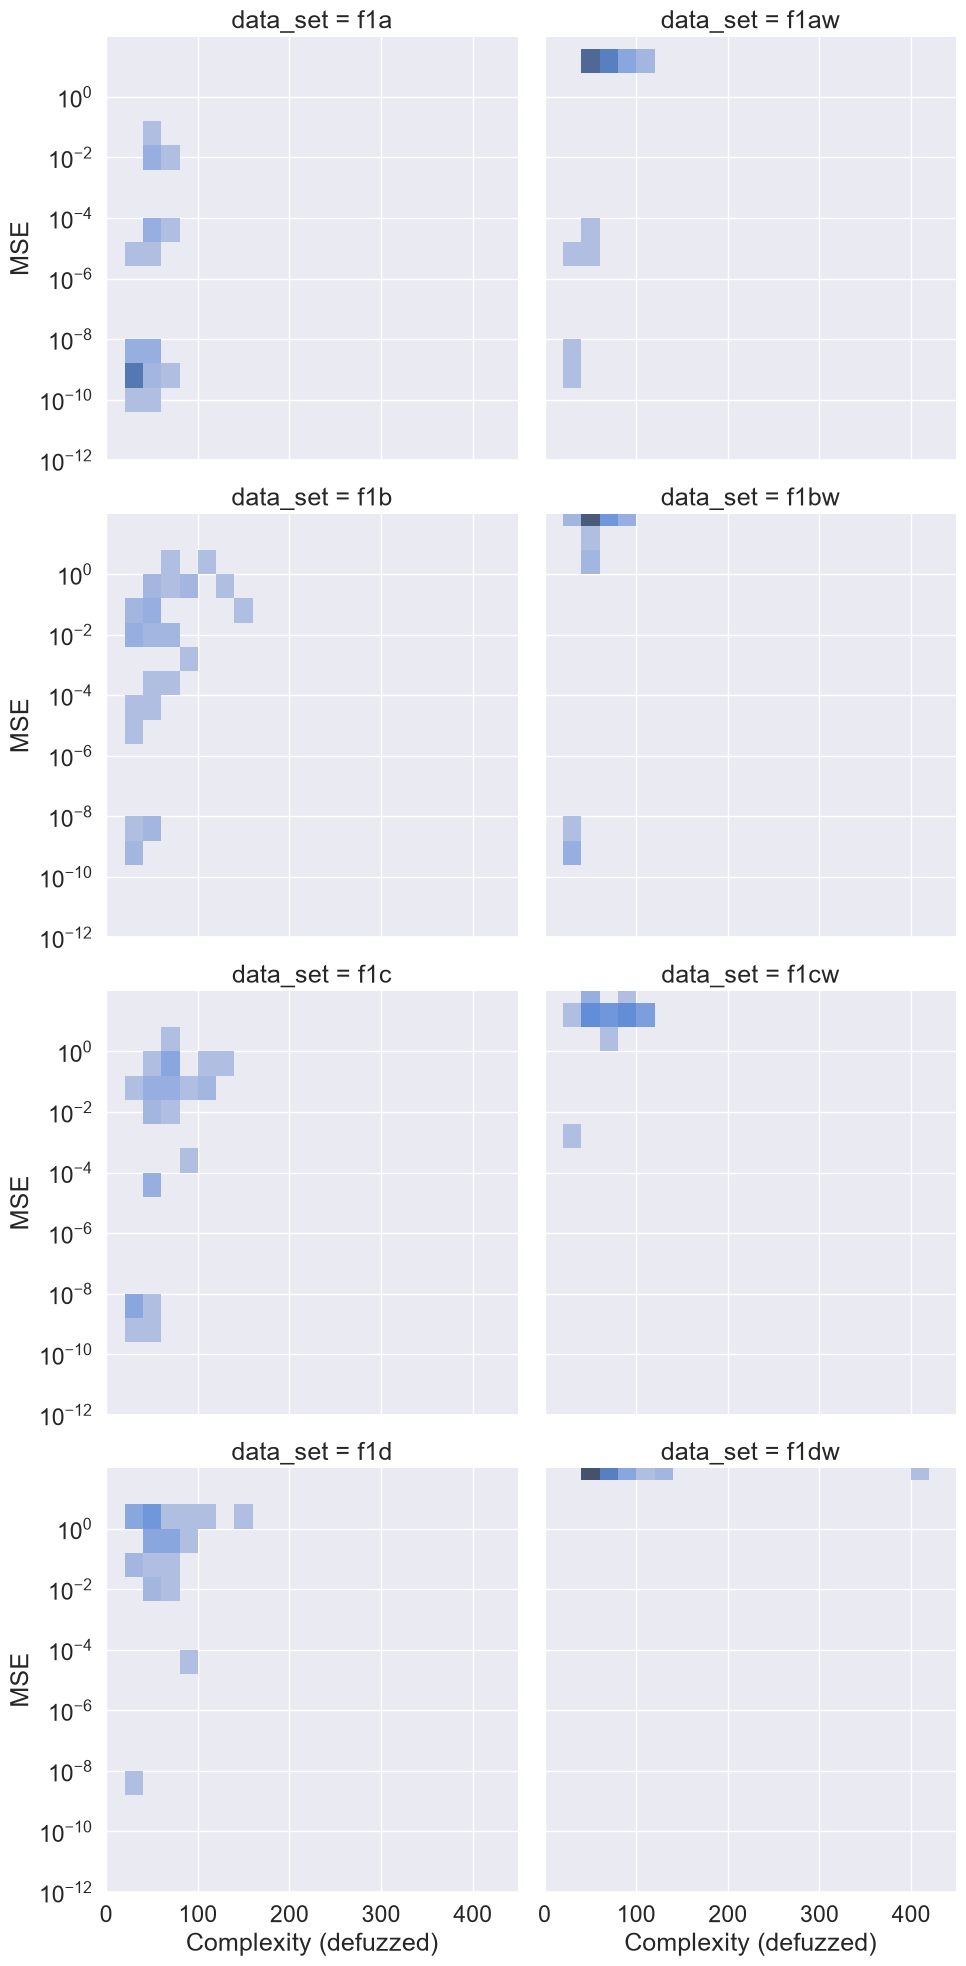

In [23]:
fig = au.complexity_mse_displot(srb, file_stem="SRB-complexity-mse-displot", **plot_params)

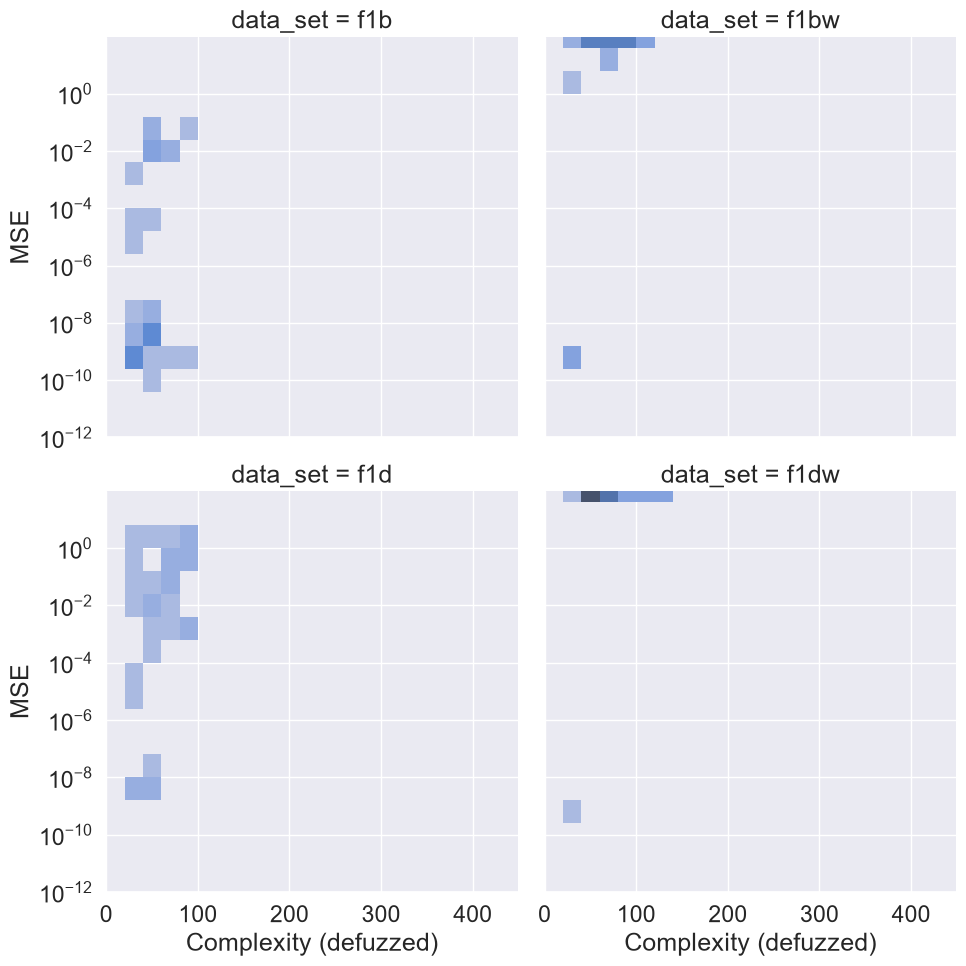

In [24]:
au.complexity_mse_displot(srbs, file_stem="srbs-complexity-mse-displot", **plot_params_bd)

In [25]:
au.count_by_threshold(srb, threshold=1.0e-7)

data_set
f1a     21
f1aw     2
f1b      5
f1bw     4
f1c      7
f1cw     0
f1d      1
f1dw     0
Name: mse, dtype: int64

In [26]:
au.count_by_threshold(srbs, threshold=1.0e-7)

data_set
f1b     19
f1bw     3
f1d      5
f1dw     1
Name: mse, dtype: int64

A lot of trig cruft.

In [27]:
srb.loc["f1a"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=1.0e-5))

sample_num
26    -1.525780275780606e-5*x1 + 20.00001760768665*x...
24    -3.52378171989641e-5*x1 + 20.0000436042291*x3*...
7     20.000011561052685*x3**2 - 20*x3 + 10.00095761...
17    19.9999799773381*x3**2 - 20.00001622986858*x3 ...
30    19.999979573470053*x3**2 - 19.999986159790407*...
22    -9.978397143446567e-5*x2**2 + 1.34200054591532...
16    5.797146643035534e-5*x1**2 + 20*x3**2 - 20*x3 ...
29    19.999859041238081*x3**2 - 19.999837872435542*...
12    20*x3**2 - 20*x3 + 3.3441748111660017e-5*x4**2...
9     7.7824242759372275e-5*x1 + 0.00022279992237351...
20    0.00045303934493477009*x3**4 + 19.999175761203...
15    19.99996444267119*x3**2 - 19.999972388272722*x...
1     19.99997063767501*x3**2 - 19.999978325617482*x...
13    1.126415514277993e-5*x1**2*x3*x5 + 1.126415514...
23    -9.208403507617555e-5*x1 - 1.278520742321531e-...
11    0.00011236267310452027*x1**2 + 1.5525164401292...
32    19.997590275307168*x3**2 - 20.000156436180302*...
4     -1.56275482863079e-5*x1**2*x2 +

In [28]:
srb.loc["f1a"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=1e-4))

sample_num
26    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
24    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
7     20*x3**2 - 20*x3 + 10.00095761412252*x4 + 5*x5...
17    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
30    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
22    -0.00020156613070172985*x2*x5**2 + 0.000172447...
16    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
29    19.999859041238081*x3**2 - 19.999837872435542*...
12    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
9     0.00022279992237351546*x2**2*x4 + 20.000248214...
20    0.00045303934493477009*x3**4 + 19.999175761203...
15    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
1     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
13    -0.0001652750606980003*x1*x5 + 0.0002521574027...
23    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
11    0.00011236267310452027*x1**2 + 0.0002247253462...
32    19.997590275307168*x3**2 - 20.000156436180302*...
4     20*x3**2 - 20*x3 + 10*x4 + 5*x5

There are 22 clearly correct here:

In [29]:
srb.loc["f1a"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e).evalf(), tolerance=0.02))

sample_num
26    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
24    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
7     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
17    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
30    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
22    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
16    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
29    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
12    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
9     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
20    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
15    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
1     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
13    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
23    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
11    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
32    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
4     20*x3**2 - 20*x3 + 10*x4 + 5*x5

In [30]:
srb.loc["f1b"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e).evalf(), tolerance=1.0e-5))

sample_num
22    -1.48599153158781e-5*x1 + 20*x3**2 - 20.000071...
15    20*x3**2 - 19.9998817509651*x3 + 9.99998556337...
29    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
32    -0.0002616755387752*x1**2 + 0.0002616755387752...
25    0.000154815264707064*x1 - 0.000880761280081128...
21    -20.0462893088242*x3 + 10.0041703756577*x4 + 4...
7     -6.15532851447236*x3 - 0.0498836166608504*x4**...
18    0.000654836739585981*x1*x2 + 0.000208439027923...
8     333.550218478813*x1**3*x2**3 - 2266.7047239180...
12    44.300143700957*x1**3*x2**3 - 0.00059693253981...
20    0.0164140247699817*x1 + 19.9169391432508*x3**2...
19    -351.09658110883*x1*x2 + 0.00199677065974861*x...
13    -0.0412126473260599*x1 + 19.8893637466116*x3**...
6     -12.1126345093512*x1**3*x2**3 - 0.015050345998...
1     89.5300649627229*x1*x2 - 0.149088308450429*x2 ...
9     0.00214705141527209*x1**2 + 0.0042941028305441...
14    -0.000440548549649868*x1**7*x2**7 - 0.01106440...
2     -0.00440943020386954*x1**6*x2**

In [31]:
srb.loc["f1b"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e).evalf(), tolerance=0.02))

sample_num
22    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
15    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
29    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
32    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
25    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
21    -20.0462893088242*x3 + 10*x4 + 5*x5 + 10*sin(3...
7     -6.15532851447236*x3 - 0.0498836166608504*x4**...
18    10*x4 + 5*x5 + 239.657011423709*sin(x3) + 10*s...
8     333.550218478813*x1**3*x2**3 - 2266.7047239180...
12    44.300143700957*x1**3*x2**3 + 30.9147294215867...
20    19.9169391432508*x3**2 - 19.7776327830599*x3 -...
19    -351.09658110883*x1*x2 - 21.6144474442925*x3 +...
13    -0.0412126473260599*x1 + 19.8893637466116*x3**...
6     -12.1126345093512*x1**3*x2**3 - 25.84901071589...
1     89.5300649627229*x1*x2 - 0.149088308450429*x2 ...
9     9.93557950820794*x4 + 5*x5 + 4.96778975410397*...
14    -0.158790493628776*x1**5*x2**5 - 1.42429796337...
2     -3.83136584616141*x1**6*x2**6 -

In [32]:
srb.loc["f1c"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e).evalf(), tolerance=0.02))

sample_num
26    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
21    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
6     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
2     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
3     20*x3**2 - 20*x3 + 10*x4 + 5*x5 - 0.0220901860...
13    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
28    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
29    -0.0358949644040991*x3 + 10*x4 + 5*x5 + 10*sin...
14    10*x4 + 5*x5 + 10*sin(3.14125692687338*x1*x2) ...
20    -3.05687252690011*x3 + 10*x4 + 5*x5 + 10*sin(3...
32    10*x4 + 5*x5 + 10*sin(3.1401091781114503*x1*x2...
8     80.5439676953713*x1*x2 - 0.0428011095648009*x2...
1     10*x4 + 0.0480866180532906*x9**3 + 5.830029360...
24    -0.0597974191046702*x1**7 - 0.0597974191046702...
19    -40.8800438049949*x1**2*x2**2 - 0.054859256372...
12    109.685350308239*x1*x2 + 0.099717223331795*x10...
27    -0.0217893468654244*x10 + 20.264873726219*x3**...
4     -33.9308951058267*x1**3*x2**3 +

In [33]:
srb.loc["f1d"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e).evalf(), tolerance=0.02))

sample_num
3     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
7     0.0453681280575151*x3 + 10*x4 + 5*x5 + 10*sin(...
16    -0.0539183354796896*x1*x10 + 10.0398001628664*...
9     -0.0420423599983122*x1**3*x4 + 0.0900948995815...
20    89.226132550112*x1*x2 - 0.553708132637364*x3**...
32    -1.34606445400094*x1**2*x2**3 - 39.14781475405...
11    41.6075064947054*x1*x2 + 20*x3**2 - 20.0457460...
5     -12.0814925090124*x1**3*x2**3 - 0.091268579501...
19    -14.5346010752264*x1**3*x2**3 + 0.637275217400...
22    -5.23941643871128*x1**2*x2**2 - 9.325334260347...
1     -12.9367040586108*x1**3 - 38.8101121758325*x1*...
31    -x1**2*x2**2*exp(x5) - 34.8846130385285*x1**2*...
14    0.054115978041112*x10/(x3**0.5 + 2) + 0.799948...
25    -19.7311578183123*x1**3*x2**3 - 7.638637224434...
29    -0.0508358323407007*x1**4*x2**6 - 0.1984198049...
26    0.0619237814255622*x1 + 20.2539427023678*x3**2...
2     -0.0409055497987663*x1**18*x5**9 - 0.037758969...
8     -2.30447712561604*x10**2 + 2.29

## Does sub-setting help with the large data set?

In [34]:
srbs.loc["f1b"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=0.02))

sample_num
16    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
27    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
2     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
23    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
6     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
10    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
17    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
21    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
25    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
18    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
15    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
32    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
24    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
7     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
5     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
8     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
12    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
29    10*x4 + 5*x5 + 10*sin(3.1415881

In [35]:
srbs_f1d = srbs.loc["f1d"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=0.02))
srbs_f1d

sample_num
15    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
30    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
13    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
21    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
27    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
16    -26.216082420485858*sqrt(x3) + 258.93566452128...
26    10*x4 + 5*x5 + 10*sin(3.1411470082593116*x1*x2...
24    19.972347624322061*x3**2 - 19.976106568324394*...
28    -0.48432837933277072*x1 - 0.48432837933277072*...
2     20.11974666739121*x3**2 - 20.22929527269653*x3...
14    10.080253410940906*x3**4*x4**2 - 20.1697050429...
11    -1.9023263222210176*x2 - 1.8557578923299042*x3...
3     0.07718716445131392*x1 + 0.07718716445131392*s...
9     19.961757245173*x3**2 - 19.943562372200212*x3 ...
4     -0.03740764168788681*x2**2 + 0.074815283375773...
1     -80.194672300187916*x1*x2 - 4*x3*sin(cos(x5)) ...
22    -7.584836485944127*x1**3*x2**3 - 30.8956104776...
23    0.032922761764881927*x10 + 0.02

Here's a good example of cruft.

In [36]:
srbs_f1d.loc[26]

10*x4 + 5*x5 + 10*sin(3.1411470082593116*x1*x2) - 40.69602087679726*sin(x3 + 1.0707997996504899) + 40.683086276304234

In [37]:
srbs.loc[("f1d", 26), "sympy"]

0.0024197909494918513*x10 - 0.0026167679401638555*x2 + 0.0024197909494918513*x3 + 10.00113950591387*x4 - 0.004411563402680818*x5**3 + 5.0058511967050137*x5 + 10.001571596253349*sin(3.1411470082593116*x1*x2) - 40.69602087679726*sin(x3 + 1.0707997996504899) + 40.683086276304234

In [38]:
print(sympy.latex(srbs_f1d.loc[26]))

10 x_{4} + 5 x_{5} + 10 \sin{\left(3.1411470082593116 x_{1} x_{2} \right)} - 40.69602087679726 \sin{\left(x_{3} + 1.0707997996504899 \right)} + 40.683086276304234


In [39]:
sympy.series(-40.696*sympy.sin(x+1)+40.683, x, 0, 3).evalf()

6.43849680225784 - 21.9881426396098*x + 17.1222515988711*x**2 + O(x**3)

In [40]:
sympy.expand(20*(x - 1/2)**2)

20*x**2 - 20.0*x + 5.0

## Larger $\lambda_b$

I tried everything again with $\lambda_b = 10^{-10}$ to see what effect it would have on fuzz.
These are the `srb3` trials.

In [41]:
srb3.loc["f1a"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e).evalf(), tolerance=5e-4))

sample_num
11    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
5     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
32    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
30    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
21    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
24    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
13    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
22    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
7     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
18    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
19    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
1     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
16    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
4     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
26    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(39269...
9     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
20    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
6     20*x3**2 - 20*x3 + 10*x4 + 5*x5

In [42]:
srb3.loc["f1b"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e).evalf(), tolerance=5e-4))

sample_num
15    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
22    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
20    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(78540...
12    -0.000630500710107303*x1*x3 + 20*x3**2 - 20*x3...
7     -0.074705699080674*x1 - 0.0012901754443171*x2*...
30    14.5672412521212*x3**2 - 0.0215068245175112*x4...
8     0.00113463891567573*x2 - 0.0246515346458324*x3...
21    -0.0215737489304416*x2**2*x3**2 - 0.1294424935...
14    0.0101116207768612*x3**6 + 0.0202232415537225*...
4     -0.0214467840135437*x2 - 0.0214467840135437*x3...
24    0.169118938650181*x2*x3 + 0.169118938650181*x3...
13    0.00118810978695454*x2**3 - 0.0035643293608636...
31    0.0375903557113131*x1 - 0.0126395202156902*x2 ...
3     -80.2085843263573*x1*x2 - 0.645678597697104*x3...
29    -12.7077278828189*x1**3*x2**3 - 26.10962263885...
16    0.347053099060995*x1 - 0.0142827022502424*x2 -...
19    -198.927101670872*x1*x2 - 0.649220245937723*x1...
1     1.69656420609247*x1**6 + 0.0166

In [43]:
srb3.loc["f1c"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e).evalf(), tolerance=5e-4))

sample_num
24    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
18    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
8     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
5     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
25    -0.000619562230410015*x1*x3*sin(3.141547606232...
30    20.0020928021724*x3**2 - 20.0017843361793*x3 +...
31    -0.0013036807739297*x1*x5 - 0.0061567399978418...
21    0.000925677078834235*x1*x2 + 0.000589343800799...
28    0.0817637632207915*x3 + 9.98860818605185*x4 + ...
16    -0.0793079639023839*x3 + 0.0793079639023839*x4...
6     0.125340518480846*x10 + 10.026357934951*x4 + 1...
13    -13.8318726538696*x1**3*x2**3 - 24.53960350124...
19    93.9161462771009*x1*x2 + 0.943992858543353*x3*...
14    91.0289484722975*x1*x2 - 40.1184676706487*x3 +...
20    -9.9504286903548*x1 + 0.0142374887507011*x10 +...
3     69.7443393814732*x3 + 10.0529983844807*x4 + 0....
12    -0.0258436776475247*x1 - 0.0258436776475247*x1...
29    -0.00694591396043326*x1**3*x2 -

In [44]:
srb3.loc["f1d"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e).evalf(), tolerance=5e-4))

sample_num
30    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
26    0.0031286440909134*x10 + 19.9845809450056*x3**...
11    -11.5876162912554*x1**3*x2**3 - 26.45675584708...
7     -0.0227351546766516*x1**2*x2**2 + 0.0454703093...
29    13.0118626377571*x3**3 - 11.6544999300268*x3 +...
2     -1.01158651055013*x1 - 0.515303572650298*x10 -...
23    0.832656215797325*x2*x5 + 4.20835054825819*x3*...
12    -0.464538702178888*x1*x3 - 0.464538702178888*x...
24    -5.16982637090441*x1*x2 + 0.309728245885384*x1...
14    -0.0475147962392814*x10 + 0.386377796760015*x2...
17    0.186786038190841*x1**3 - 0.560358114572523*x1...
31    0.443259910299633*x3 + 10.0022724387325*x4 + 5...
15    94.7290972909611*x1*x2 + 3.73032015015211*x1 -...
18    0.611273056834768*x1**2*x4 + 0.072878054810276...
9     -15.0619983197207*x1**3*x2**3 - 22.26595777041...
25    9.56115400011533*x1**2 - 14.4536625850956*x1 -...
16    57.8004806063585*x3 + 10.070526081362*x4 + 6.0...
5     277.76400637561*x1*x2 + 4.83078

In [45]:
srb3s.loc["f1b"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e).evalf(), tolerance=5e-4))

sample_num
3     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
21    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
6     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
24    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
28    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
29    20*x3**2 - 19.999292729695*x3 + 10*x4 + 5*x5 +...
26    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
27    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
23    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
11    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
19    -0.00304991257192862*x3**0.5 + 19.998171901078...
2     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
31    -0.000642622106022876*x2 + 19.9994520340503*x3...
12    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
8     20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
25    -40.4867428578349*x3 + 10*x4 + 5*x5 + 12.11308...
15    -33.4149796336115*x3 + 10*x4 + 5*x5 + 10*exp(x...
5     -0.00065331751050024*x2 - 0.000

In [46]:
srb3s.loc["f1d"].iloc[0:10].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e).evalf(), tolerance=5e-4))

sample_num
27    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
19    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
17    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
21    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
6     20.0120821615532*x3**2 - 19.9986917714729*x3 +...
28    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
10    20*x3**2 - 20*x3 + 10*x4 + 5*x5 + 10*sin(3.141...
22    0.0200447268526187*x3**2*x4 + 0.02004472685261...
26    0.00137909279120409*x1*x10 - 0.003566596973005...
5     -0.00782464571404011*x2 + 0.132918944306182*x3...
Name: sympy, dtype: object